In [1]:
%cd /home/govind/gov_semproject/GridCellsCopy

/home/govind/gov_semproject/GridCellsCopy


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sim_utils as s_utils
import analysis_utils as a_utils
import g_utils
import seaborn as sns
import pandas as pd


Hallelujah
Stellate File Path :  data/final_0_o/stell_spks_final_0_o.hdf5
Interneuron File Path :  data/final_0_o/intrnrn_spks_final_0_o.hdf5


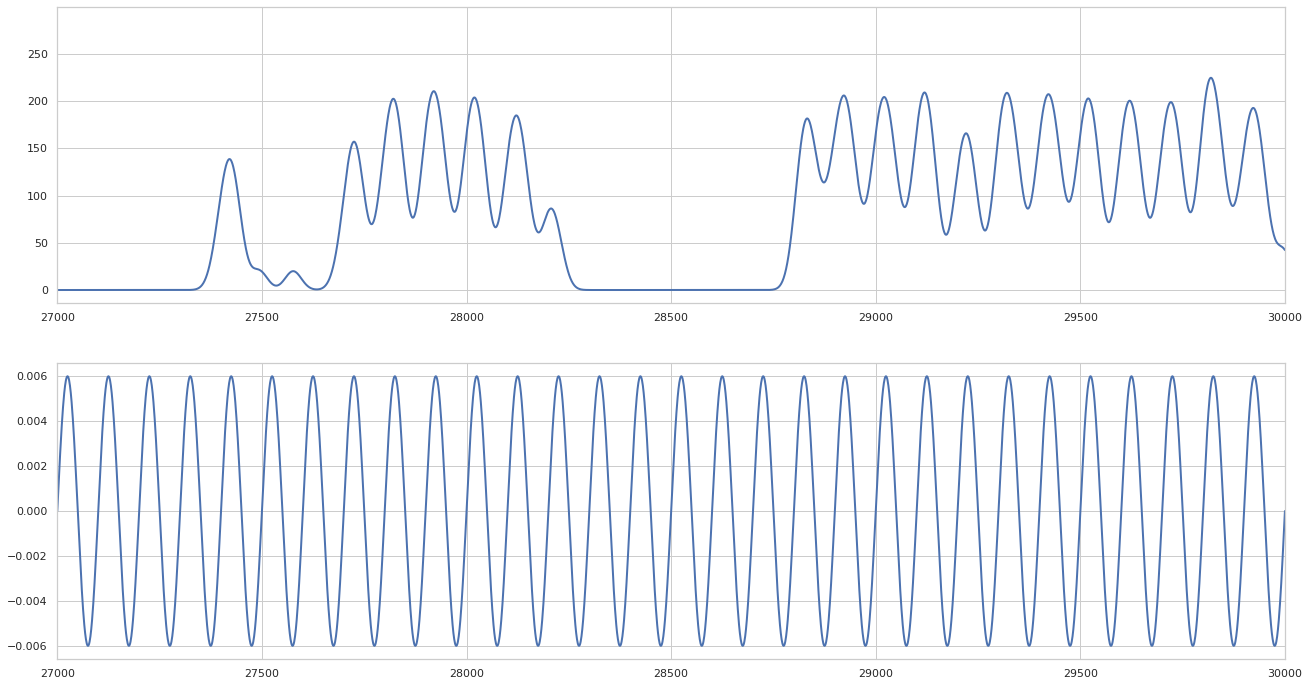

In [46]:
stell_spks,intrnrn_spks = s_utils.load_spikes(sim_id='final_0_o',sim_num=0)
theta_curr = s_utils.load_data(sim_id='final_0_o',sim_num=0,data_id='intrnrn_theta_dc')
firing_rate = a_utils.instant_rate(sim_dur=30000,spike_train=intrnrn_spks[0],stdev=20)*1000

time_arr = np.linspace(0,len(firing_rate),len(firing_rate))


fig,ax = plt.subplots(2,1,figsize=(22,12))
ax[0].plot(time_arr,firing_rate)
ax[0].set_xlim(27000,30000)

ax[1].plot(time_arr,theta_curr[1:])
ax[1].set_xlim(27000,30000)

plt.show()

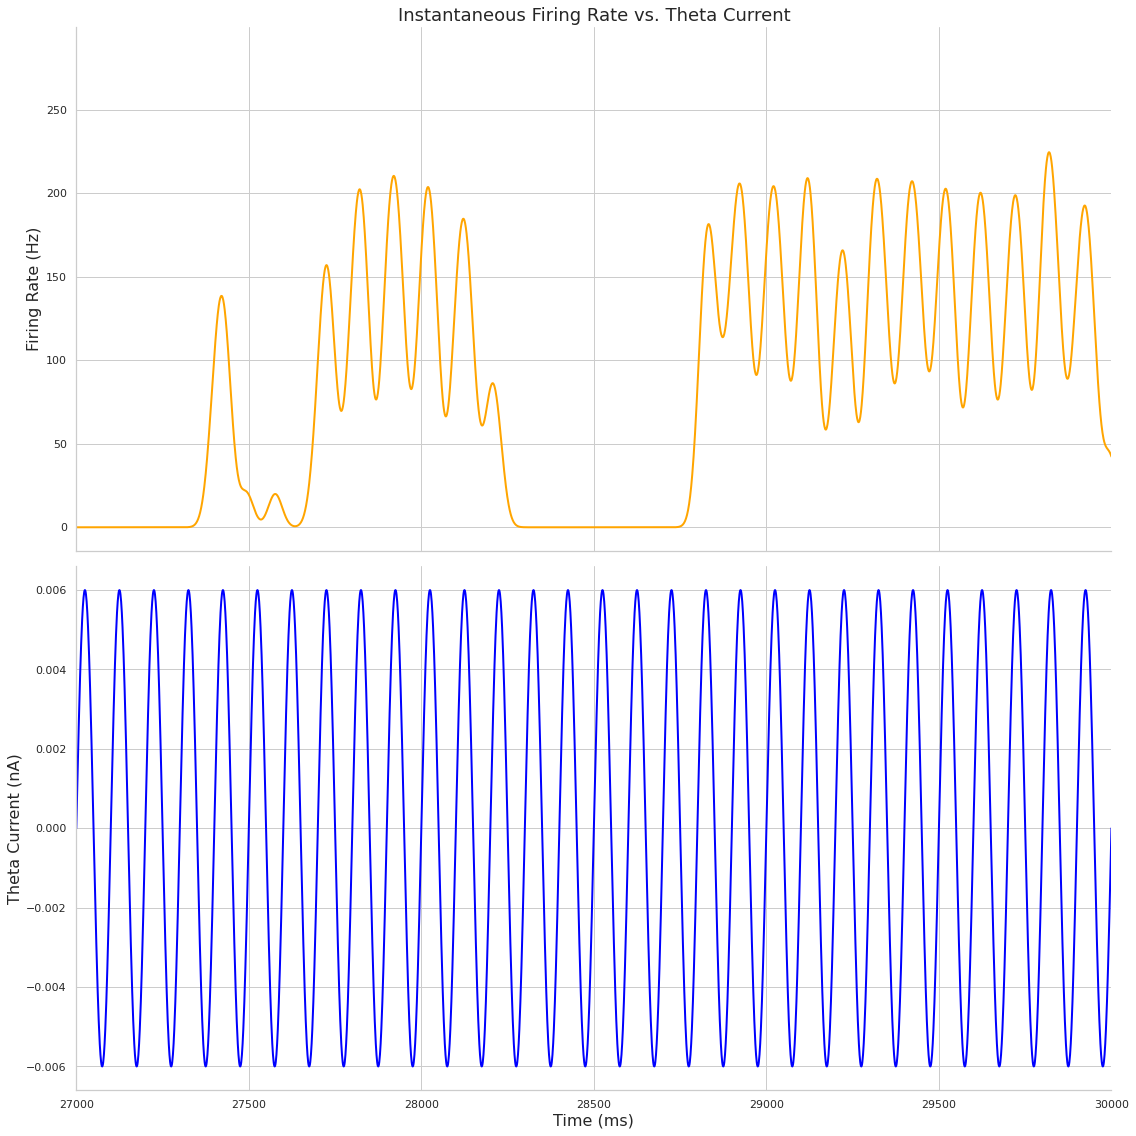

In [72]:
sns.set_theme(style="whitegrid")    # clean aesthetic style
plt.rcParams.update({
    "font.family" :'Helvetica',
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "figure.titlesize": 20,
    "lines.linewidth": 2.0,
})

# --- Create figure ---
fig, ax = plt.subplots(2, 1, figsize=(16, 16), sharex=True)

# --- Upper panel: firing rate ---
ax[0].plot(
    time_arr, firing_rate,
    color='orange',
    label="Firing Rate"
)
ax[0].set_xlim(27000, 30000)
ax[0].set_ylabel("Firing Rate (Hz)")
ax[0].set_title("Instantaneous Firing Rate vs. Theta Current")
#ax[0].legend(frameon=False)

# Optional: subtle highlight region
#ax[0].axvspan(27000, 30000, color='gray', alpha=0.05)

# --- Lower panel: theta current ---
ax[1].plot(
    time_arr, theta_curr[1:],
    color='blue',
    label="Theta Current"
)
ax[1].set_xlim(27000, 30000)
ax[1].set_xlabel("Time (ms)")
ax[1].set_ylabel("Theta Current (nA)")
#ax[1].legend()

# Remove clutter
sns.despine()
plt.tight_layout()
plt.savefig("FiringRateTheta.png",dpi=600)
plt.show()